# Probabilistic Graphical Models — Belief Architecture
### `02_PGM_Causal_Logic/Belief_Architecture/`

> **Learning goal:** Build the mathematical engine of causal reasoning — from raw probability (Murphy Ch.2) through Bayesian Networks, d-separation, and exact inference. This is the formal bridge between "pattern matching over correlations" (what LLMs do) and "reasoning over causes" (what a causal agent must do).

> **Primary references:** Murphy, *Probabilistic Machine Learning* (2022) §2, §4. Pearl, *Causality* (2000) Ch.1–2.

---

## Proof-read Notes (before reading further)

"> **Note:** older versions of networkx used `nx.algorithms.d_separated`, while `nx.d_separated(G, X, Y, Z)` is the correct function in networkx >= 2.6. The original code caused an issue.\n",
> **Conceptual note fixed:** The claim that "a standard Transformer has no mechanism for explaining away" is directionally correct but needs nuance — see §4.

---

## 1. The Probability Foundation (Murphy Ch. 2 — The Math You Need)

### 1A. The Three Objects

A **probability space** $(\Omega, \mathcal{F}, P)$ consists of:
- $\Omega$: the sample space — all possible outcomes
- $\mathcal{F}$: the event space — all measurable subsets of $\Omega$
- $P: \mathcal{F} \to [0,1]$: the probability measure

**Random variables** map events to numbers. Two regimes:

| Type | Tool | Key formula |
|---|---|---|
| Discrete | PMF $p_X(a) = P[X=a]$ | $\sum_a p_X(a) = 1$ |
| Continuous | PDF $p_X(x)$ | $P([a,b]) = \int_a^b p_X(x)\,dx$ |

**Kolmogorov axioms:** $P[E] \geq 0$; $P[\Omega] = 1$; countable additivity over disjoint events.

### 1B. The Four Rules You Use Every Day

**Conditional probability:**
$$P[E_1 \mid E_2] = \frac{P[E_1 \cap E_2]}{P[E_2]}$$

**Law of Total Probability:**
$$P[B] = \sum_i P[B \mid A_i]\,P[A_i]$$

**Bayes' Rule:**
$$P[\theta \mid \mathcal{D}] = \frac{P[\mathcal{D} \mid \theta]\,P[\theta]}{P[\mathcal{D}]}$$

$$\underbrace{P[\theta \mid \mathcal{D}]}_{\text{posterior}} = \frac{\underbrace{P[\mathcal{D} \mid \theta]}_{\text{likelihood}} \cdot \underbrace{P[\theta]}_{\text{prior}}}{\underbrace{P[\mathcal{D}]}_{\text{evidence}}}$$

**Independence:** $P[E_1 \cap E_2] = P[E_1]\,P[E_2]$

**Conditional Independence** (the key operation in PGMs):
$$X \perp\!\!\!\perp Y \mid Z \quad \Leftrightarrow \quad P[X, Y \mid Z] = P[X \mid Z]\,P[Y \mid Z]$$

### 1C. Distributions That Matter for PGMs

The following are the distributions you will encounter inside Bayesian networks:

**Categorical / Multinomial** — discrete node with $K$ states:
$$\text{Cat}(x \mid \theta) = \prod_{k=1}^K \theta_k^{x_k}, \qquad \sum_k \theta_k = 1$$

**Dirichlet** — the conjugate prior over $\theta$ in a Categorical:
$$\text{Dir}(x \mid \alpha) = \frac{1}{B(\alpha)}\prod_{k=1}^K x_k^{\alpha_k - 1}$$

**Gaussian / MVN** — continuous nodes and Kalman filters:
$$\mathcal{N}(x \mid \mu, \Sigma) = \frac{1}{(2\pi)^{D/2}|\Sigma|^{1/2}} \exp\!\left(-\tfrac{1}{2}(x-\mu)^T \Sigma^{-1}(x-\mu)\right)$$

**KL Divergence** — the loss function that connects everything:
$$D_{\text{KL}}(p \| q) = \int p(x) \ln \frac{p(x)}{q(x)}\,dx \geq 0$$

Asymmetric: $D_{\text{KL}}(p\|q) \neq D_{\text{KL}}(q\|p)$ in general.
- **Forward KL** (inclusive): $q$ must cover all modes of $p$ — used in maximum likelihood
- **Reverse KL** (exclusive/mode-seeking): $q$ collapses to one mode of $p$ — used in variational inference / VAEs

---

## 2. Bayesian Networks — Causal Structure as a DAG

### 2A. The "Everything is Connected" Problem

A fully-connected joint distribution over $n$ binary variables requires $2^n - 1$ parameters. For $n = 30$: over a billion parameters, just to store the distribution.

**The Bayesian Network solution:** Represent the joint distribution as a **Directed Acyclic Graph (DAG)** where each node only depends on its direct parents.

$$\boxed{P(x_1, \ldots, x_n) = \prod_{i=1}^n P(x_i \mid \text{Pa}(x_i))}$$

This is the **Factorization Theorem** (Murphy §4.2). It is the only reason probabilistic AI can operate at scale.

**Complexity reduction:** If each node has at most $k$ parents and $d$ states, the full joint needs $d^n$ parameters. The factored form needs only $n \cdot d^{k+1}$.

### 2B. The Markov Blanket

Every node $v$ is conditionally independent of *all other nodes in the network* given its **Markov Blanket**:

$$\text{MB}(v) = \text{Parents}(v) \cup \text{Children}(v) \cup \text{Co-Parents}(v)$$

(Co-parents = other parents of $v$'s children.)

This is the mathematical foundation of **local computation**: to update a node's belief, you only need to talk to its immediate neighbours — not the entire graph.

---

## 3. D-Separation — The Logic of Causality

D-separation answers: *given what I've observed ($Z$), are $X$ and $Y$ conditionally independent?*

A path from $X$ to $Y$ is **blocked** (d-separated) given $Z$ if it contains at least one of:
1. A **chain** or **fork** node in $Z$, or
2. A **collider** node (and all its descendants) *not* in $Z$

If *all* paths between $X$ and $Y$ are blocked given $Z$, then $X \perp\!\!\!\perp Y \mid Z$.

### 3A. The Three Canonical Motifs

#### Motif 1: The Chain (Causal Pipe) $X \to Z \to Y$

$$P(X,Y,Z) = P(X)\,P(Z \mid X)\,P(Y \mid Z)$$

- **Without $Z$ observed:** $X$ and $Y$ are **dependent** (information flows through $Z$)
- **With $Z$ observed:** $X \perp\!\!\!\perp Y \mid Z$ — the pipe is **blocked**

*Example:* Alarm → Wake-up → Late for work. If you know you woke up, whether the alarm rang gives no extra info about being late.

#### Motif 2: The Fork (Common Cause) $X \leftarrow Z \rightarrow Y$

$$P(X,Y,Z) = P(Z)\,P(X \mid Z)\,P(Y \mid Z)$$

- **Without $Z$ observed:** $X$ and $Y$ are **dependent** (spurious correlation via $Z$)
- **With $Z$ observed:** $X \perp\!\!\!\perp Y \mid Z$ — the fork is **blocked**

*Example:* Shoe size ← Age → Reading level. Conditioning on Age removes the correlation.  
*Causal reasoning:* This is **confounding**. $Z$ is the confounder; blocking it eliminates the spurious association.

#### Motif 3: The Collider (Common Effect) $X \to Z \leftarrow Y$

$$P(X,Y,Z) = P(X)\,P(Y)\,P(Z \mid X,Y)$$

- **Without $Z$ observed:** $X \perp\!\!\!\perp Y$ — they are **independent**
- **With $Z$ observed:** $X$ and $Y$ become **dependent** — the path is **opened**

*Example:* Rain → Wet Grass ← Sprinkler. Without observing the grass, rain and the sprinkler are independent. Observe the grass is wet → now they compete to explain it (**Berkson's Paradox / Explaining Away**).

| Motif | Unobserved middle node | Observed middle node |
|---|---|---|
| Chain $X \to Z \to Y$ | Dependent | **Independent** |
| Fork $X \leftarrow Z \rightarrow Y$ | Dependent | **Independent** |
| Collider $X \to Z \leftarrow Y$ | **Independent** | Dependent |

### 3B. Why This Separates PGMs from LLMs

A large language model trained on text *can* implicitly learn collider effects from data — if the training corpus contains enough counterfactual examples ("the grass is wet and the sprinkler is on, so it probably didn't rain"). What LLMs fundamentally **cannot** do is reliably generalise to **novel interventions** — the $\text{do}(\cdot)$ operator:

$$P(\text{WetGrass} \mid \text{do}(\text{Rain}=\text{True})) \neq P(\text{WetGrass} \mid \text{Rain}=\text{True})$$

The left side requires *cutting* the incoming edges to Rain in the DAG (Pearl's do-calculus). This requires an explicit causal graph. An LLM that has only seen observational data conflates "Rain is observed to be true" with "Rain is forcibly set to true" — the classic **correlation vs. causation** failure mode.

---

## 4. Inference Algorithms

### 4A. Variable Elimination

The exact inference workhorse for discrete PGMs.

**Goal:** Compute $P(X_q \mid \mathbf{x}_e)$ — the query variable given evidence.

**Algorithm:** Choose an elimination ordering for hidden variables. For each hidden variable:
1. Collect all factors (CPTs) that mention it
2. Multiply them together into a new factor
3. Sum out the hidden variable

**Complexity:** $\mathcal{O}(n \cdot d^{w+1})$ where $w$ is the **treewidth** of the graph and $d$ is the state-space size. For tree-structured graphs, $w=1$ and inference is linear.

### 4B. Belief Propagation (Sum-Product Algorithm)

On **tree-structured** graphs, variable elimination with the right ordering gives the **belief propagation** algorithm — passing messages between neighbouring nodes.

Each node $i$ sends a message to neighbour $j$:

$$\mu_{i \to j}(x_j) = \sum_{x_i} \phi_i(x_i) \cdot \psi_{ij}(x_i, x_j) \prod_{k \in \text{Ne}(i) \setminus j} \mu_{k \to i}(x_i)$$

After convergence, the marginal belief at node $i$ is:

$$b_i(x_i) \propto \phi_i(x_i) \prod_{j \in \text{Ne}(i)} \mu_{j \to i}(x_i)$$

On trees: **exact** in one forward-backward pass. On graphs with cycles: **Loopy BP** (approximate but often works well in practice — used in turbo codes and early vision systems).

---


## 6. The do-Calculus — Observation vs. Intervention

The deepest gap between correlational AI and causal AI:

$$\underbrace{P(Y \mid X=x)}_{\text{observe } X=x} \quad \neq \quad \underbrace{P(Y \mid \text{do}(X=x))}_{\text{force } X=x}$$

**Observational:** "Given that the road is wet, what is $P(\text{Rain})$?" — you are conditioning, keeping all causal paths intact.

**Interventional:** "If I forcibly turn on the sprinkler, what is $P(\text{WetGrass})$?" — you *cut* all incoming edges to Sprinkler, removing the Cloudy → Sprinkler path. This is Pearl's **do-calculus**.

$$P(Y \mid \text{do}(X=x)) = \sum_z P(Y \mid X=x, Z=z)\,P(Z=z)$$

(The **backdoor adjustment formula**, valid when $Z$ blocks all backdoor paths into $X$.)

**Why LLMs cannot do this reliably:** An LLM trained only on observational text conflates these two quantities. It has seen countless examples of "road is wet → probably rained" but has not been trained to distinguish "observing rain" from "intervening to make it rain." This is the causal inference gap — the reason PGMs with explicit graph structure remain essential for reasoning agents.

---

## 7. Concept Map

```
Belief Architecture (PGM)
│
├── Probability Foundations (Murphy Ch.2)
│   ├── Bayes' Rule: posterior ∝ likelihood × prior
│   ├── Conditional Independence: P(X,Y|Z) = P(X|Z)P(Y|Z)
│   └── KL Divergence: forward (inclusive) vs reverse (mode-seeking)
│
├── Bayesian Networks
│   ├── DAG: nodes = RVs, edges = direct causal influence
│   ├── Factorization: P(x1..xn) = prod P(xi | Pa(xi))
│   └── Markov Blanket: parents + children + co-parents
│       -> local computation: only MB needed for a node's belief
│
├── D-Separation (Pearl 1988)
│   ├── Chain X->Z->Y:    obs Z blocks path
│   ├── Fork X<-Z->Y:     obs Z blocks path (de-confounding)
│   └── Collider X->Z<-Y: obs Z OPENS path (explaining away / Berkson)
│
├── Inference Algorithms
│   ├── Variable Elimination: sum-product over hidden variables
│   ├── Belief Propagation: message passing on trees (exact)
│   └── Loopy BP: approximate on graphs with cycles
│
└── Observation vs. Intervention
    ├── P(Y|X=x): conditioning (observational)
    ├── P(Y|do(X=x)): intervention (cut incoming edges to X)
    └── Gap: LLMs trained on observational data conflate these
```

---

## 8. Summary Table

| Concept | Math | AI / Causal Agent Relevance |
|---|---|---|
| Factorization | $\prod_i P(x_i \mid \text{Pa}(x_i))$ | Tractable world models at scale |
| Markov Blanket | Parents ∪ Children ∪ Co-parents | Local belief updates; attention pattern analogy |
| Chain (blocked) | $X \perp\!\!\!\perp Y \mid Z$, $X\to Z\to Y$ | Controlling a mediator removes indirect effect |
| Fork (blocked) | $X \perp\!\!\!\perp Y \mid Z$, $X\leftarrow Z\to Y$ | Conditioning on confounder removes spurious corr. |
| Collider (opened) | $X \not\perp Y \mid Z$, $X\to Z\leftarrow Y$ | Explaining away; Berkson's paradox |
| Forward KL | $D_{\text{KL}}(P\|Q)$ | MLE, moment matching — covers all modes |
| Reverse KL | $D_{\text{KL}}(Q\|P)$ | VAE ELBO — collapses to one mode |
| do-calculus | $P(Y\mid\text{do}(X))$ vs $P(Y\mid X)$ | The formal causal inference gap |

---

## 9. References

- Murphy, K. P. (2022) — *Probabilistic Machine Learning: An Introduction*, Ch. 2, 4. MIT Press.
- Pearl, J. (1988) — *Probabilistic Reasoning in Intelligent Systems*. Morgan Kaufmann.
- Pearl, J. (2000) — *Causality: Models, Reasoning, and Inference*. Cambridge University Press.
- Pearl, J. (2018) — *The Book of Why*. Basic Books.
- Koller, D. & Friedman, N. (2009) — *Probabilistic Graphical Models*. MIT Press.
- Jordan, M. I. (1998) — *Learning in Graphical Models*. MIT Press.
- Spirtes, P., Glymour, C. & Scheines, R. (2001) — *Causation, Prediction and Search*. MIT Press.

Prior P(Disease) = 0.010
P(+ | Disease)   = 0.950
P(+ | Healthy)   = 0.050
Posterior P(Disease | +) = 0.1610
Intuition: even with 95% sensitivity, a +ve test means only 16.1% chance of disease


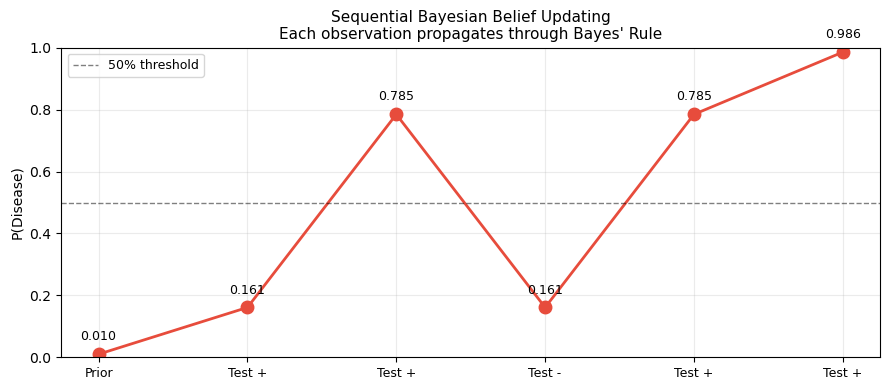

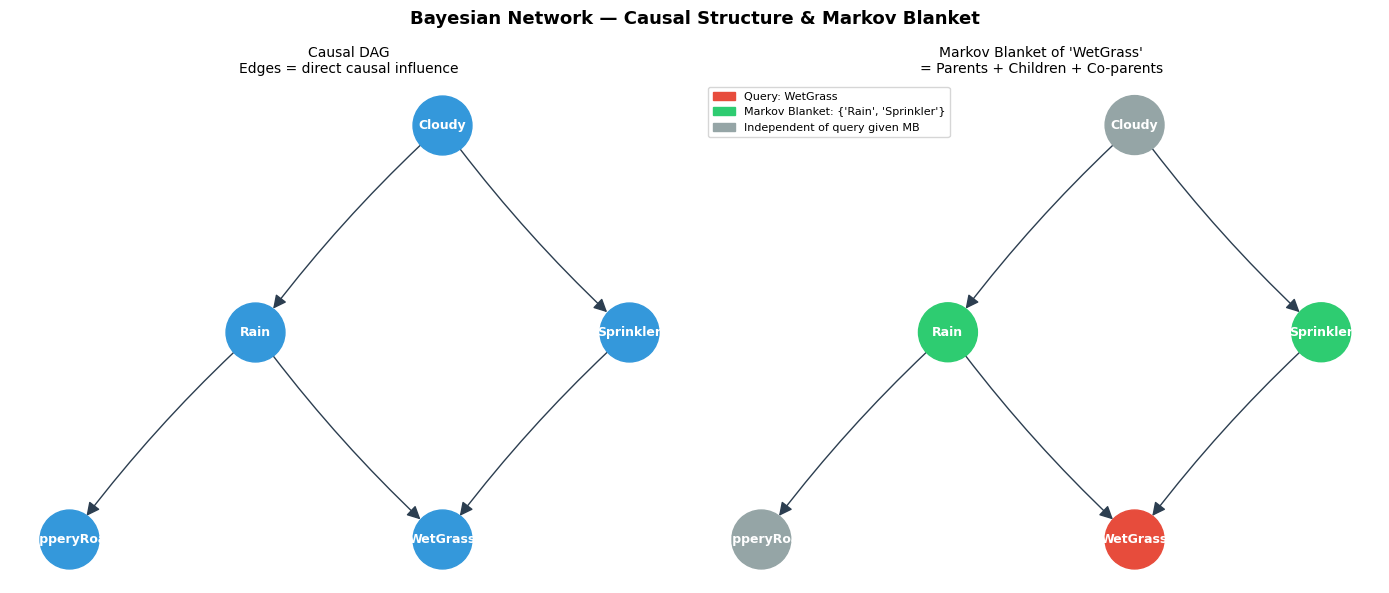

Markov Blanket of WetGrass: {'Rain', 'Sprinkler'}
WetGrass is conditionally independent of Cloudy given its Markov Blanket.
CAUSAL LOGIC AUDIT — D-Separation Tests

✓ Fork: Rain ⊥ Sprinkler | ∅  (nothing observed)
   Result: DEPENDENT
   Why: Cloudy is an unblocked fork → spurious correlation

✓ Fork: Rain ⊥ Sprinkler | Cloudy  (observe common cause)
   Result: INDEPENDENT
   Why: Conditioning on the fork blocks the path

✓ Collider: Rain ⊥ Sprinkler | WetGrass  (observe common effect)
   Result: DEPENDENT
   Why: Conditioning on collider OPENS the path (Berkson's paradox)

✓ Chain: Cloudy ⊥ WetGrass | Rain  (observe mediator)
   Result: DEPENDENT
   Why: Sprinkler provides a second unblocked path Cloudy→Sprinkler→WetGrass

✓ Chain: Cloudy ⊥ WetGrass | Rain, Sprinkler  (block both paths)
   Result: INDEPENDENT
   Why: Both paths from Cloudy to WetGrass are now blocked

✓ Direct: Rain ⊥ SlipperyRoad | ∅
   Result: DEPENDENT
   Why: Rain directly causes SlipperyRoad

✓ Sprinkler ⊥ Slippe

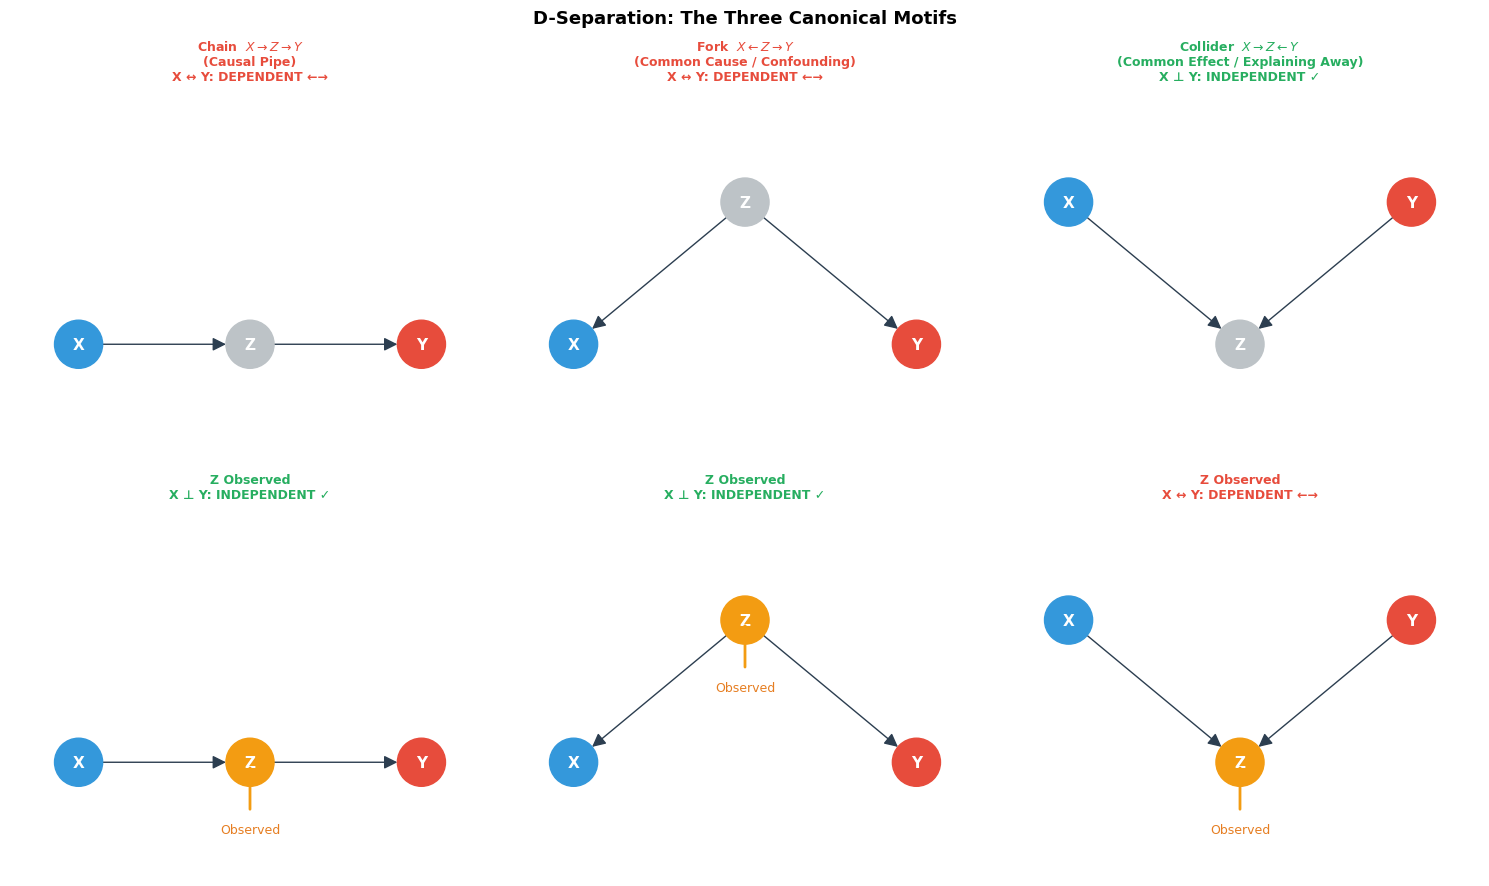

P(WetGrass = True) = 0.6500
P(WetGrass = False) = 0.3500

No evidence
  P(Rain=T)      = 0.5000
  P(Sprinkler=T) = 0.3000

WetGrass observed True
  P(Rain=T)      = 0.7048
  P(Sprinkler=T) = 0.4278

WetGrass=T AND Sprinkler=T (Explaining Away)
  P(Rain=T)      = 0.3204
  P(Sprinkler=T) = 1.0000

WetGrass=T AND Rain=T (Explaining Away other direction)
  P(Rain=T)      = 1.0000
  P(Sprinkler=T) = 0.1945



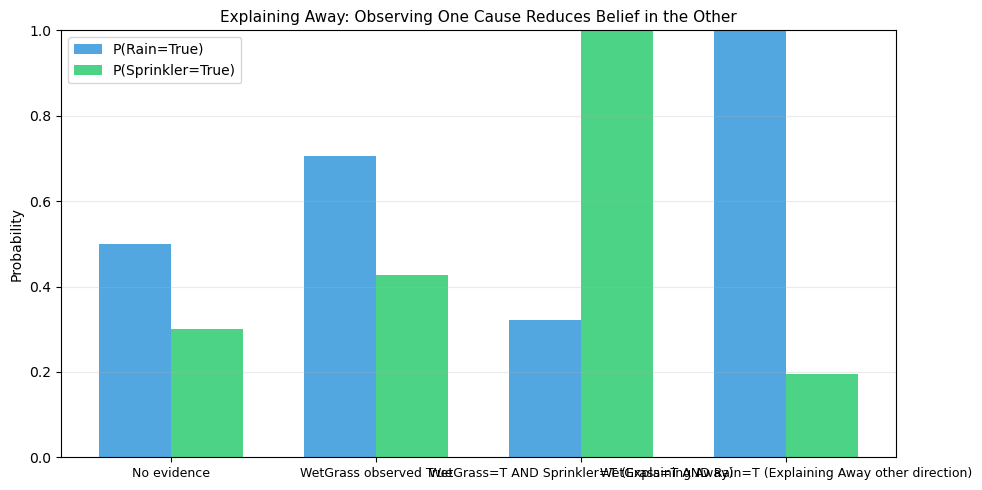

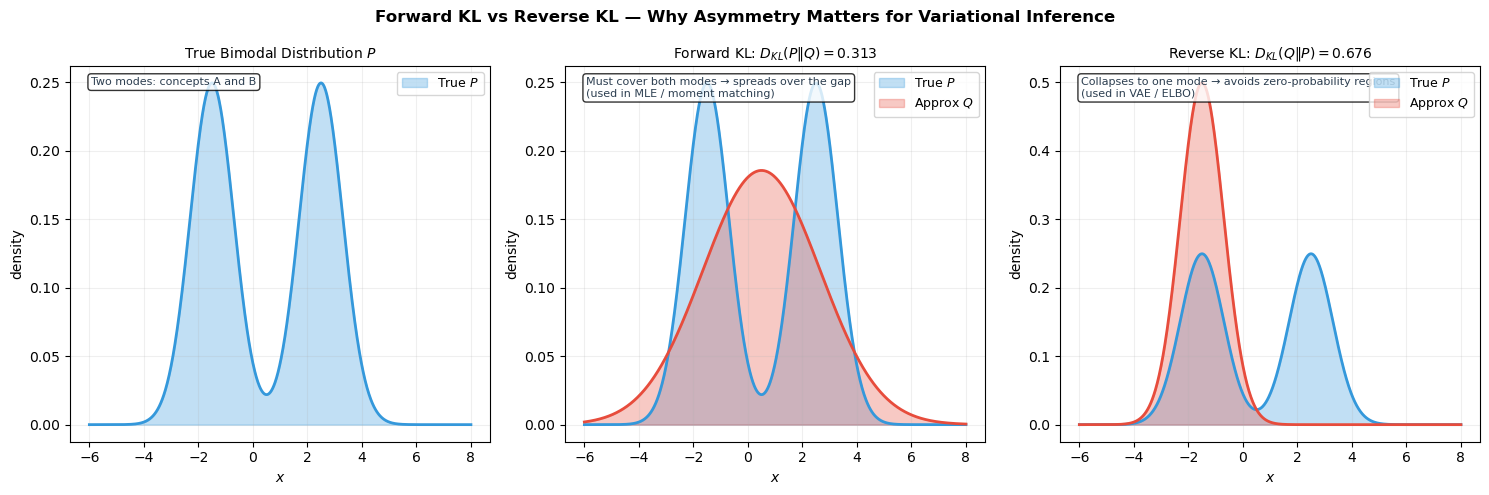

In [2]:
## 5. Code — Five Implementations

### 5A. Probability Foundations — Bayes' Rule and Updating Beliefs


import numpy as np
import matplotlib.pyplot as plt

# ── Discrete Bayes' Rule: Medical Test Example ────────────────────────────────
# P(Disease) = 0.01, P(+|Disease) = 0.95, P(+|Healthy) = 0.05
def bayes_update(prior, likelihood_given_true, likelihood_given_false):
    """Bayes update: posterior = likelihood * prior / evidence."""
    evidence = (likelihood_given_true * prior +
                likelihood_given_false * (1 - prior))
    return likelihood_given_true * prior / evidence

p_disease = 0.01
p_pos_given_disease = 0.95
p_pos_given_healthy  = 0.05

posterior = bayes_update(p_disease, p_pos_given_disease, p_pos_given_healthy)
print(f"Prior P(Disease) = {p_disease:.3f}")
print(f"P(+ | Disease)   = {p_pos_given_disease:.3f}")
print(f"P(+ | Healthy)   = {p_pos_given_healthy:.3f}")
print(f"Posterior P(Disease | +) = {posterior:.4f}")
print(f"Intuition: even with 95% sensitivity, a +ve test means only "
      f"{posterior*100:.1f}% chance of disease")

# ── Sequential updating: multiple test results ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
belief = p_disease
beliefs = [belief]
test_results = [1, 1, 0, 1, 1]   # 1=positive, 0=negative
labels       = ["Prior"]

for result in test_results:
    like_true  = p_pos_given_disease if result == 1 else (1 - p_pos_given_disease)
    like_false = p_pos_given_healthy  if result == 1 else (1 - p_pos_given_healthy)
    belief = bayes_update(belief, like_true, like_false)
    beliefs.append(belief)
    labels.append(f"Test {'+'if result else '-'}")

ax.plot(beliefs, "o-", color="#E74C3C", lw=2, ms=9)
ax.axhline(0.5, color="black", ls="--", lw=1, alpha=0.5, label="50% threshold")
for i, (b, l) in enumerate(zip(beliefs, labels)):
    ax.annotate(f"{b:.3f}", (i, b), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_xticks(range(len(beliefs)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("P(Disease)")
ax.set_title("Sequential Bayesian Belief Updating\n"
             "Each observation propagates through Bayes' Rule", fontsize=11)
ax.set_ylim(0, 1); ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("5A_bayes_update.png", dpi=150, bbox_inches="tight")
plt.show()


### 5B. Build the Causal DAG + Markov Blanket Visualisation


import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def build_causal_world():
    """Classic sprinkler DAG — the canonical PGM teaching example."""
    G = nx.DiGraph()
    G.add_nodes_from(["Cloudy", "Rain", "Sprinkler", "WetGrass", "SlipperyRoad"])
    G.add_edges_from([
        ("Cloudy",    "Rain"),
        ("Cloudy",    "Sprinkler"),
        ("Rain",      "WetGrass"),
        ("Sprinkler", "WetGrass"),
        ("Rain",      "SlipperyRoad"),
    ])
    return G

def markov_blanket(G, node):
    """
    Returns the Markov Blanket of a node:
    parents + children + co-parents (other parents of node's children).
    """
    parents   = set(G.predecessors(node))
    children  = set(G.successors(node))
    coparents = set()
    for child in children:
        for p in G.predecessors(child):
            if p != node:
                coparents.add(p)
    return parents | children | coparents

G = build_causal_world()

pos = {
    "Cloudy":     (2.0,  2.0),
    "Rain":       (1.0,  1.0),
    "Sprinkler":  (3.0,  1.0),
    "WetGrass":   (2.0,  0.0),
    "SlipperyRoad":(0.0, 0.0),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Bayesian Network — Causal Structure & Markov Blanket",
             fontsize=13, fontweight="bold")

# ── Panel 1: Full DAG ─────────────────────────────────────────────────────────
ax1 = axes[0]
nx.draw_networkx(G, pos=pos, ax=ax1,
                 node_color="#3498DB", node_size=1800,
                 font_color="white", font_weight="bold", font_size=9,
                 edge_color="#2C3E50", arrows=True,
                 arrowstyle="-|>", arrowsize=20,
                 connectionstyle="arc3,rad=0.05")
ax1.set_title("Causal DAG\nEdges = direct causal influence", fontsize=10)
ax1.axis("off")

# ── Panel 2: Markov Blanket of WetGrass ───────────────────────────────────────
ax2 = axes[1]
query_node = "WetGrass"
mb = markov_blanket(G, query_node)

colors = []
for node in G.nodes():
    if node == query_node:
        colors.append("#E74C3C")       # query node = red
    elif node in mb:
        colors.append("#2ECC71")       # MB = green
    else:
        colors.append("#95A5A6")       # outside MB = grey

nx.draw_networkx(G, pos=pos, ax=ax2,
                 node_color=colors, node_size=1800,
                 font_color="white", font_weight="bold", font_size=9,
                 edge_color="#2C3E50", arrows=True,
                 arrowstyle="-|>", arrowsize=20,
                 connectionstyle="arc3,rad=0.05")

patches = [
    mpatches.Patch(color="#E74C3C", label=f"Query: {query_node}"),
    mpatches.Patch(color="#2ECC71", label=f"Markov Blanket: {mb}"),
    mpatches.Patch(color="#95A5A6", label="Independent of query given MB"),
]
ax2.legend(handles=patches, fontsize=8, loc="upper left")
ax2.set_title(f"Markov Blanket of '{query_node}'\n"
              f"= Parents + Children + Co-parents", fontsize=10)
ax2.axis("off")

plt.tight_layout()
plt.savefig("5B_dag_markov_blanket.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Markov Blanket of {query_node}: {markov_blanket(G, query_node)}")
print(f"WetGrass is conditionally independent of Cloudy given its Markov Blanket.")


### 5C. D-Separation — Full Causal Audit


import networkx as nx

G = build_causal_world()   # from 5B

print("=" * 60)
print("CAUSAL LOGIC AUDIT — D-Separation Tests")
print("=" * 60)

tests = [
    # (X_set, Y_set, Z_set, description, expected)
    ({"Rain"}, {"Sprinkler"}, set(),
     "Fork: Rain ⊥ Sprinkler | ∅  (nothing observed)",
     False,   # NOT independent — correlated via Cloudy
     "Cloudy is an unblocked fork → spurious correlation"),

    ({"Rain"}, {"Sprinkler"}, {"Cloudy"},
     "Fork: Rain ⊥ Sprinkler | Cloudy  (observe common cause)",
     True,    # independent
     "Conditioning on the fork blocks the path"),

    ({"Rain"}, {"Sprinkler"}, {"WetGrass"},
     "Collider: Rain ⊥ Sprinkler | WetGrass  (observe common effect)",
     False,   # NOT independent — EXPLAINING AWAY
     "Conditioning on collider OPENS the path (Berkson's paradox)"),

    ({"Cloudy"}, {"WetGrass"}, {"Rain"},
     "Chain: Cloudy ⊥ WetGrass | Rain  (observe mediator)",
     False,   # NOT independent — Sprinkler path still open
     "Sprinkler provides a second unblocked path Cloudy→Sprinkler→WetGrass"),

    ({"Cloudy"}, {"WetGrass"}, {"Rain", "Sprinkler"},
     "Chain: Cloudy ⊥ WetGrass | Rain, Sprinkler  (block both paths)",
     True,    # independent
     "Both paths from Cloudy to WetGrass are now blocked"),

    ({"Rain"}, {"SlipperyRoad"}, set(),
     "Direct: Rain ⊥ SlipperyRoad | ∅",
     False,   # direct causal path
     "Rain directly causes SlipperyRoad"),

    ({"Sprinkler"}, {"SlipperyRoad"}, set(),
     "Sprinkler ⊥ SlipperyRoad | ∅",
     False,   # Sprinkler → WetGrass, and Rain → SlipperyRoad, Rain via Cloudy
     "Correlated via Cloudy→Rain→SlipperyRoad"),

    ({"Sprinkler"}, {"SlipperyRoad"}, {"Rain"},
     "Sprinkler ⊥ SlipperyRoad | Rain",
     True,    # Rain blocks the only path Sprinkler←Cloudy→Rain→SlipperyRoad
     "Conditioning on Rain blocks all paths"),
]

for X, Y, Z, desc, expected, explanation in tests:
    result = nx.d_separated(G, X, Y, Z)
    status = "✓" if result == expected else "✗ BUG"
    indep_str = "INDEPENDENT" if result else "DEPENDENT"
    print(f"\n{status} {desc}")
    print(f"   Result: {indep_str}")
    print(f"   Why: {explanation}")


### 5D. The Three Motifs — Visual Proof


import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("D-Separation: The Three Canonical Motifs",
             fontsize=13, fontweight="bold")

motifs = [
    # (title, edges, X, Y, Z_unobserved, Z_observed, pos_dict)
    ("Chain  $X \\to Z \\to Y$\n(Causal Pipe)",
     [("X","Z"),("Z","Y")],
     "X", "Y", set(), {"Z"},
     {"X":(0,1), "Z":(1,1), "Y":(2,1)}),

    ("Fork  $X \\leftarrow Z \\rightarrow Y$\n(Common Cause / Confounding)",
     [("Z","X"),("Z","Y")],
     "X", "Y", set(), {"Z"},
     {"X":(0,1), "Z":(1,2), "Y":(2,1)}),

    ("Collider  $X \\to Z \\leftarrow Y$\n(Common Effect / Explaining Away)",
     [("X","Z"),("Y","Z")],
     "X", "Y", set(), {"Z"},
     {"X":(0,2), "Z":(1,1), "Y":(2,2)}),
]

for col, (title, edges, Xn, Yn, Z_un, Z_ob, pos) in enumerate(motifs):
    for row, (Z, panel_title, bg) in enumerate([
        (Z_un, "Unobserved", "#FDFEFE"),
        (Z_ob, "Z Observed", "#FDFEFE"),
    ]):
        ax = axes[row][col]
        G = nx.DiGraph(); G.add_edges_from(edges)
        observed = list(Z)

        colors = []
        for n in G.nodes():
            if n == Xn: colors.append("#3498DB")
            elif n == Yn: colors.append("#E74C3C")
            elif n in Z: colors.append("#F39C12")
            else: colors.append("#BDC3C7")

        is_indep = nx.d_separated(G, {Xn}, {Yn}, Z)
        dep_str  = "INDEPENDENT ✓" if is_indep else "DEPENDENT ←→"
        dep_col  = "#27AE60" if is_indep else "#E74C3C"

        nx.draw_networkx(G, pos=pos, ax=ax, node_color=colors,
                         node_size=1200, font_color="white",
                         font_weight="bold", font_size=11,
                         edge_color="#2C3E50", arrows=True,
                         arrowstyle="-|>", arrowsize=20)
        if observed:
            for obs_node in observed:
                ax.annotate("", xy=pos[obs_node],
                            xytext=(pos[obs_node][0], pos[obs_node][1]-0.35),
                            arrowprops=dict(arrowstyle="->", color="#F39C12", lw=2))
            ax.text(pos[list(observed)[0]][0], pos[list(observed)[0]][1]-0.5,
                    "Observed", ha="center", fontsize=9, color="#E67E22")

        ax.set_title(f"{title if row==0 else panel_title}\n"
                     f"X {'⊥' if is_indep else '↔'} Y: {dep_str}",
                     fontsize=9, color=dep_col, fontweight="bold")
        ax.set_facecolor(bg); ax.axis("off")
        ax.set_xlim(-0.4, 2.4); ax.set_ylim(0.2, 2.8)

plt.tight_layout()
plt.savefig("5C_dsep_motifs.png", dpi=150, bbox_inches="tight")
plt.show()


### 5E. Variable Elimination — Computing P(WetGrass)

import numpy as np
import matplotlib.pyplot as plt
import itertools

# ── CPTs (Conditional Probability Tables) ────────────────────────────────────
# P(Cloudy)
P_C = {True: 0.5, False: 0.5}

# P(Rain | Cloudy)
P_R_C = {True:  {True: 0.8, False: 0.2},
          False: {True: 0.2, False: 0.8}}

# P(Sprinkler | Cloudy)
P_S_C = {True:  {True: 0.1, False: 0.9},
          False: {True: 0.5, False: 0.5}}

# P(WetGrass | Rain, Sprinkler)
P_WG_RS = {
    (True,  True):  {True: 0.99, False: 0.01},
    (True,  False): {True: 0.90, False: 0.10},
    (False, True):  {True: 0.90, False: 0.10},
    (False, False): {True: 0.01, False: 0.99},
}

# P(SlipperyRoad | Rain)
P_SR_R = {True: {True: 0.7, False: 0.3},
           False:{True: 0.0, False: 1.0}}

def variable_elimination_WG():
    """
    Compute P(WetGrass=T) by summing out Cloudy, Rain, Sprinkler.
    Demonstrates the factor multiplication and marginalization steps.
    """
    total = 0.0
    factor_log = []
    for c in [True, False]:
        for r in [True, False]:
            for s in [True, False]:
                joint = (P_C[c] *
                         P_R_C[c][r] *
                         P_S_C[c][s] *
                         P_WG_RS[(r,s)][True])
                factor_log.append({
                    "C": c, "R": r, "S": s,
                    "P(C)": P_C[c],
                    "P(R|C)": P_R_C[c][r],
                    "P(S|C)": P_S_C[c][s],
                    "P(WG=T|R,S)": P_WG_RS[(r,s)][True],
                    "joint": joint,
                })
                total += joint
    return total, factor_log

p_wg_true, factor_table = variable_elimination_WG()

print(f"P(WetGrass = True) = {p_wg_true:.4f}")
print(f"P(WetGrass = False) = {1-p_wg_true:.4f}\n")

# Conditional queries
def query(wg_val, evidence=None):
    """Compute P(WetGrass=wg_val | evidence dict) via normalisation."""
    evidence = evidence or {}
    total = {True: 0, False: 0}
    for c in [True, False]:
        if "Cloudy" in evidence and evidence["Cloudy"] != c: continue
        for r in [True, False]:
            if "Rain" in evidence and evidence["Rain"] != r: continue
            for s in [True, False]:
                if "Sprinkler" in evidence and evidence["Sprinkler"] != s: continue
                for wg in [True, False]:
                    if "WetGrass" in evidence and evidence["WetGrass"] != wg: continue
                    joint = (P_C[c] * P_R_C[c][r] * P_S_C[c][s] *
                             P_WG_RS[(r,s)][wg])
                    total[wg] += joint
    Z = total[True] + total[False]
    return total[wg_val] / Z if Z > 0 else 0

# Explaining Away demonstration
cases = [
    ({}, "No evidence"),
    ({"WetGrass": True}, "WetGrass observed True"),
    ({"WetGrass": True, "Sprinkler": True},
     "WetGrass=T AND Sprinkler=T (Explaining Away)"),
    ({"WetGrass": True, "Rain": True},
     "WetGrass=T AND Rain=T (Explaining Away other direction)"),
]

fig, ax = plt.subplots(figsize=(10, 5))
labels, rain_probs, spr_probs = [], [], []
for ev, desc in cases:
    p_rain = query(True, {**ev, "WetGrass": True} if "WetGrass" not in ev else ev)
    # compute P(Rain=T | evidence)
    p_r = query(True, evidence={k: v for k,v in ev.items()})
    # more direct: compute explicitly
    total_r, total_all = 0, 0
    for c in [True,False]:
        for r in [True,False]:
            for s in [True,False]:
                for wg in [True,False]:
                    ev_match = all(
                        (c if k=="Cloudy" else r if k=="Rain" else
                         s if k=="Sprinkler" else wg) == v
                        for k,v in ev.items()
                    )
                    if ev_match:
                        j = P_C[c]*P_R_C[c][r]*P_S_C[c][s]*P_WG_RS[(r,s)][wg]
                        total_all += j
                        if r: total_r += j
    p_r = total_r/total_all if total_all > 0 else 0

    total_s, total_all2 = 0, 0
    for c in [True,False]:
        for r in [True,False]:
            for s in [True,False]:
                for wg in [True,False]:
                    ev_match = all(
                        (c if k=="Cloudy" else r if k=="Rain" else
                         s if k=="Sprinkler" else wg) == v
                        for k,v in ev.items()
                    )
                    if ev_match:
                        j = P_C[c]*P_R_C[c][r]*P_S_C[c][s]*P_WG_RS[(r,s)][wg]
                        total_all2 += j
                        if s: total_s += j
    p_s = total_s/total_all2 if total_all2 > 0 else 0

    labels.append(desc); rain_probs.append(p_r); spr_probs.append(p_s)
    print(f"{desc}")
    print(f"  P(Rain=T)      = {p_r:.4f}")
    print(f"  P(Sprinkler=T) = {p_s:.4f}\n")

x  = np.arange(len(labels))
w  = 0.35
ax.bar(x - w/2, rain_probs, w, color="#3498DB", alpha=0.85, label="P(Rain=True)")
ax.bar(x + w/2, spr_probs,  w, color="#2ECC71", alpha=0.85, label="P(Sprinkler=True)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, wrap=True)
ax.set_ylabel("Probability")
ax.set_title("Explaining Away: Observing One Cause Reduces Belief in the Other",
             fontsize=11)
ax.set_ylim(0, 1); ax.legend(fontsize=10); ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.savefig("5E_variable_elimination.png", dpi=150, bbox_inches="tight")
plt.show()


### 5F. KL Divergence — Forward vs Reverse (VAE Connection)


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def kl_divergence(p, q, dx):
    """Numerical KL(p||q) = sum p(x) log(p(x)/q(x)) dx."""
    mask = (p > 1e-10) & (q > 1e-10)
    return np.sum(p[mask] * np.log(p[mask] / q[mask])) * dx

x    = np.linspace(-6, 8, 1000)
dx   = x[1] - x[0]

# True distribution P: bimodal (mixture of two Gaussians)
p    = 0.5 * norm.pdf(x, -1.5, 0.8) + 0.5 * norm.pdf(x, 2.5, 0.8)
p   /= p.sum() * dx    # normalise

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Forward KL vs Reverse KL — Why Asymmetry Matters for Variational Inference",
             fontsize=12, fontweight="bold")

# Forward KL: minimise D_KL(P || Q) over Gaussian Q
# Solution: Q must cover both modes (mean-seeking, inclusive)
mu_fwd = np.average(x, weights=p)
var_fwd = np.average((x - mu_fwd)**2, weights=p)
q_fwd  = norm.pdf(x, mu_fwd, np.sqrt(var_fwd))
q_fwd /= q_fwd.sum() * dx

# Reverse KL: minimise D_KL(Q || P) — Q collapses to one mode (mode-seeking)
# Approximate by fitting to one mode only
q_rev = norm.pdf(x, -1.5, 0.8)
q_rev /= q_rev.sum() * dx

kl_f = kl_divergence(p, q_fwd, dx)
kl_r = kl_divergence(q_rev, p, dx)

for ax, q_approx, title, kl_val, desc in [
    (axes[0], None,   "True Bimodal Distribution $P$", None,
     "Two modes: concepts A and B"),
    (axes[1], q_fwd,  f"Forward KL: $D_{{KL}}(P\\|Q)={kl_f:.3f}$", kl_f,
     "Must cover both modes → spreads over the gap\n(used in MLE / moment matching)"),
    (axes[2], q_rev,  f"Reverse KL: $D_{{KL}}(Q\\|P)={kl_r:.3f}$", kl_r,
     "Collapses to one mode → avoids zero-probability regions\n(used in VAE / ELBO)"),
]:
    ax.fill_between(x, p, alpha=0.3, color="#3498DB", label="True $P$")
    ax.plot(x, p, "#3498DB", lw=2)
    if q_approx is not None:
        ax.fill_between(x, q_approx, alpha=0.3, color="#E74C3C", label="Approx $Q$")
        ax.plot(x, q_approx, "#E74C3C", lw=2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$x$"); ax.set_ylabel("density")
    ax.text(0.05, 0.97, desc, transform=ax.transAxes,
            va="top", fontsize=8, color="#2C3E50",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("5F_kl_divergence.png", dpi=150, bbox_inches="tight")
plt.show()

